Coide written in June 2024 to estimate the uncertainty on a multi-telescope fit.

For a uniform disk

$
|\gamma(B)| = \frac{2\,J_{1}(x)}{x}, \qquad
x = \frac{\pi B \theta}{\lambda},
$

so the intensity-correlation signal is

$
g^{(2)}(B) \;=\; 1 + |\gamma(B)|^{2}.
$

From Mathematica the derivative that links a change in diameter to a change in the measured
$g^{(2)}$ is

$
\frac{\partial g^{(2)}}{\partial \theta}
  \;=\; 2\,|\gamma| \,\frac{\partial |\gamma|}{\partial \theta},
$

with

$
\frac{\partial |\gamma|}{\partial \theta}
  \;=\; \frac{\pi B}{\lambda}\,
        \left[\,\frac{J_{0}(x)}{x} \;-\;
               \frac{2\,J_{1}(x)}{x^{2}}\,\right],
  \qquad x = \frac{\pi B \theta}{\lambda}.
$

We then build the Fischer information
$
F=\sum_{i}{} \frac{\left( \partial g^{(2)}/\partial \theta\right)_i^2}{\sigma^2_{g,i}}
$


In [1]:
import numpy as np

from pylab import *

from scipy.special import j1, j0


In [6]:
theta_mas = 1.0          # uniform-disk diameter [mas]
lambda_m = 550e-9       # wavelength [m]
baselines = np.linspace(1,300)   # [m]
baselines = np.array([1,30, 50, 80])
SNR0 = 35.0         # zero-baseline SNR on (g² – 1)


theta_rad = theta_mas / 206_265_000

x         = np.pi * baselines * theta_rad / lambda_m

# --- visibility amplitude and correlated signal ---
gamma = 2 * j1(x) / x
gamma_sq = gamma**2
sigma_g2 = np.ones_like(baselines) / SNR0
SNR = 1/sigma_g2

# --- derivative ∂g²/∂θ for a uniform disc ---
d_gamma_dθ = (np.pi * baselines / lambda_m) * ( j0(x)/x - 2*j1(x)/x**2 )
dg2_dθ     = 2 * gamma * d_gamma_dθ     # units: rad⁻¹


# Print computations
header = ("B (m)", "  x", "      |γ|", "   |γ|²", "     SNR(g²-1)", " σ[g²]", "    ∂g²/∂θ (rad⁻¹)   F_i (rad)")
print(*header)
for row in zip(baselines, x, gamma, gamma_sq, SNR, sigma_g2, dg2_dθ, dg2_dθ/sigma_g2):
    print("{:6.1f} {:7.4f} {:7.4f} {:7.4f} {:10.4f} {:8.4f} {:14.3e}, {:14.2e}".format(*row))



# Use Fischer Matrix to compute uncertainty
information = np.sum((dg2_dθ**2) / (sigma_g2**2))
sigma_theta_rad = np.sqrt(1.0 / information)
sigma_theta_mas = sigma_theta_rad * 206_265_000
fractional_error = sigma_theta_mas / theta_mas

print("The error on θ is %3.1f+- %3.2f" % (theta_mas, sigma_theta_mas))
print("SNR on       θ is %3.1f" % (1/fractional_error))



B (m)   x       |γ|    |γ|²      SNR(g²-1)  σ[g²]     ∂g²/∂θ (rad⁻¹)   F_i (rad)
   1.0  0.0277  0.9999  0.9998    35.0000   0.0286     -3.954e+04,      -1.38e+06
  30.0  0.8308  0.9162  0.8394    35.0000   0.0286     -3.077e+07,      -1.08e+09
  50.0  1.3846  0.7787  0.6065    35.0000   0.0286     -6.540e+07,      -2.29e+09
  80.0  2.2154  0.4999  0.2499    35.0000   0.0286     -8.209e+07,      -2.87e+09
The error on θ is 1.0+- 0.05
SNR on       θ is 18.6


Text(0.5, 1.0, 'Fisher information')

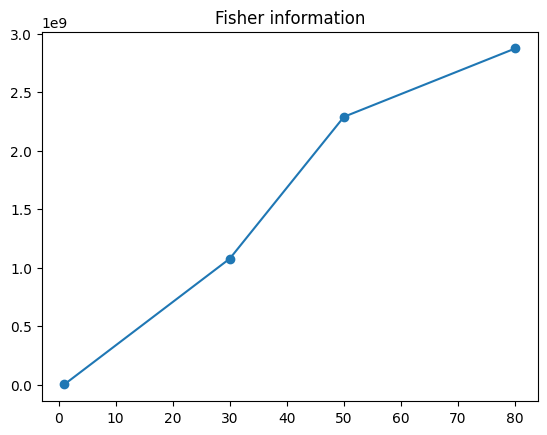

In [4]:
plot(baselines, np.abs(dg2_dθ/sigma_g2), 'o-')
title("Fisher information")

Now vibeocde an MCMC fit

θ = 0.972 (+0.024/-0.024) mas
C = 0.0503 (+0.0010/-0.0010)
SNR = 40.2


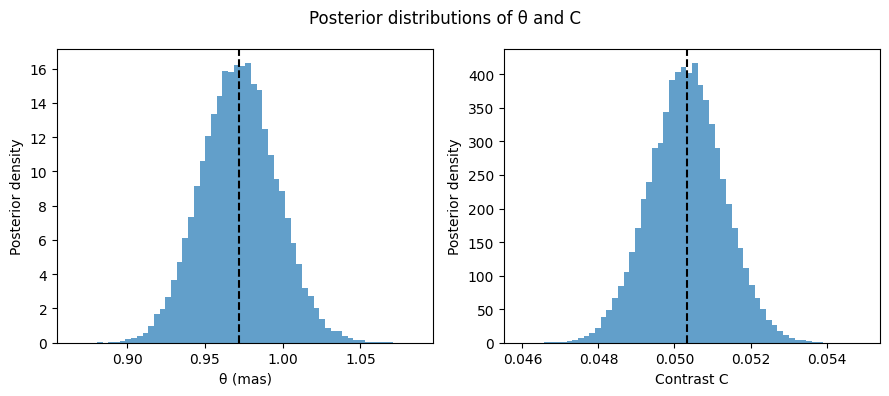

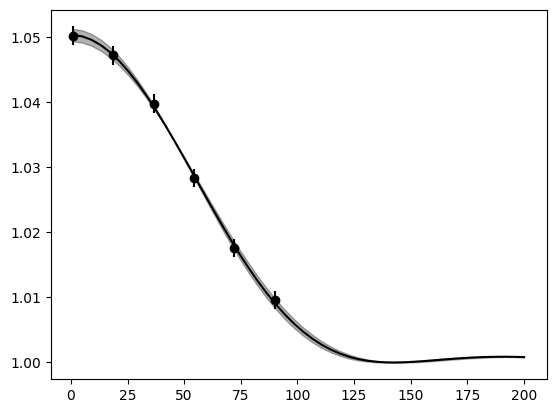

In [23]:
import numpy as np
from scipy.special import j1
import matplotlib.pyplot as plt


def go(ENDPOINT):
    # -------------------------------
    # 1.  synthetic data block
    # -------------------------------
    lambda_m = 550e-9                       # wavelength [m]
    theta_true_mas = 1.0                    # true diameter
    theta_true_rad = theta_true_mas / 206_265_000
    C_true = 0.05                           # contrast term (max g2 - 1)
    baselines = np.array([1.0, 30, 50.0, 70.0, 90, 120.0])
    baselines = np.linspace(start=1, stop=ENDPOINT, num=6)
    
    SNR0 = 35.0                             # SNR on (g2-1) at zero baseline
    sigma_g2 = C_true / SNR0                # absolute 1σ noise on each g2 point
    
    def model_g2(theta_rad, C, B):
        x = np.pi * B * theta_rad / lambda_m
        gamma = 2 * j1(x) / x
        return 1.0 + C * gamma**2
    
    #rng = np.random.default_rng(12345)
    g2_obs = model_g2(theta_true_rad, C_true, baselines) + rng.normal(0, sigma_g2, size=baselines.size)
    
    # -------------------------------
    # 2.  log‑posterior functions
    # -------------------------------
    theta_min_mas, theta_max_mas = 0.1, 5.0
    C_min, C_max = 0.0, 0.1
    
    def log_prior(theta_rad, C):
        theta_mas = theta_rad * 206_265_000
        if theta_min_mas < theta_mas < theta_max_mas and C_min < C < C_max:
            return 0.0
        return -np.inf
    
    def log_likelihood(theta_rad, C):
        g2_model = model_g2(theta_rad, C, baselines)
        return -0.5 * np.sum(((g2_obs - g2_model) / sigma_g2) ** 2)
    
    def log_posterior(theta_rad, C):
        lp = log_prior(theta_rad, C)
        return lp + log_likelihood(theta_rad, C) if np.isfinite(lp) else -np.inf
    
    # -------------------------------
    # 3.  simple Metropolis sampler
    # -------------------------------
    n_steps = 500_000
    theta_chain = np.empty(n_steps)
    C_chain = np.empty(n_steps)
    
    # initialise
    theta_chain[0] = 1.5 / 206_265_000   # 1.5 mas in rad
    C_chain[0] = 0.03
    
    prop_theta_width = 0.03 / 206_265_000  # 0.03 mas
    prop_C_width = 0.005
    
    for i in range(1, n_steps):
        cur_theta, cur_C = theta_chain[i-1], C_chain[i-1]
        prop_theta = cur_theta + rng.normal(0, prop_theta_width)
        prop_C = cur_C + rng.normal(0, prop_C_width)
        log_alpha = log_posterior(prop_theta, prop_C) - log_posterior(cur_theta, cur_C)
        if np.log(rng.uniform()) < log_alpha:
            theta_chain[i] = prop_theta
            C_chain[i] = prop_C
        else:
            theta_chain[i] = cur_theta
            C_chain[i] = cur_C
    
    burn = n_steps // 3
    theta_samples_mas = theta_chain[burn:] * 206_265_000
    C_samples = C_chain[burn:]
    
    theta_med = np.median(theta_samples_mas)
    theta_lo, theta_hi = np.percentile(theta_samples_mas, [16, 84])
    C_med = np.median(C_samples)
    C_lo, C_hi = np.percentile(C_samples, [16, 84])
    
    print(f"θ = {theta_med:.3f} (+{theta_hi-theta_med:.3f}/-{theta_med-theta_lo:.3f}) mas")
    print(f"C = {C_med:.4f} (+{C_hi-C_med:.4f}/-{C_med-C_lo:.4f})")
    print("SNR = %3.1f" % (theta_med/np.std(theta_samples_mas)))
    
    # plot corner-style quicklook
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    
    ax[0].hist(theta_samples_mas, bins=60, density=True, alpha=0.7)
    ax[0].axvline(theta_med, color='k', linestyle='--')
    ax[0].set_xlabel('θ (mas)')
    ax[0].set_ylabel('Posterior density')
    
    ax[1].hist(C_samples, bins=60, density=True, alpha=0.7)
    ax[1].axvline(C_med, color='k', linestyle='--')
    ax[1].set_xlabel('Contrast C')
    ax[1].set_ylabel('Posterior density')
    
    fig.suptitle('Posterior distributions of θ and C')
    plt.tight_layout()
    plt.show()
    
    
    plt.figure()
    plt.errorbar(baselines, g2_obs, sigma_g2, fmt='ko')
    x = np.linspace(1,200)
    plt.plot(x, model_g2(theta_med/206_265_000, C_med, x), 'k-')
    plt.fill_between(x, model_g2(theta_lo/206_265_000, C_lo, x), model_g2(theta_hi/206_265_000, C_hi, x), alpha=.3, color='black')

    return theta_med/np.std(theta_samples_mas)



go(90)


if False:
    xs = np.arange(70,120,3)
    res = []
    
    for x in xs:
        print("--- ----")
        r = go(x)
        res.append(r)
    
    plt.plot(xs, res)

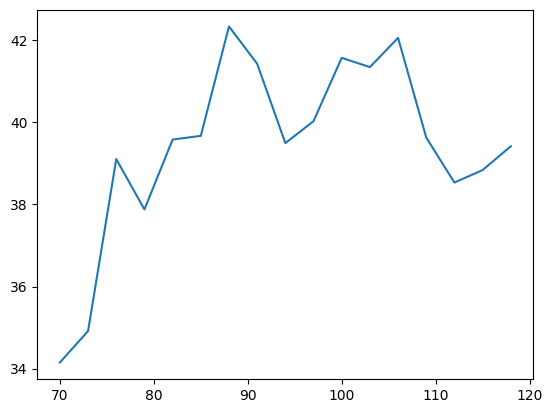

In [22]:
plot(xs, res)